
<p align="center">
  <img src="./images/Captura de pantalla 2024-11-07 193801.png" alt="Descripción de la imagen">
</p>

# 🎓 Proyecto de Machine Learning: Predicción de Éxito o Fracaso Académico 📊



## 📋 Descripción

Este proyecto tiene como objetivo desarrollar un modelo de **Machine Learning** para predecir el éxito o fracaso académico de los estudiantes en función de sus características personales, académicas y socioeconómicas. Utilizando un enfoque de **clasificación**, el modelo identificará si un estudiante tiene probabilidades de **graduarse** o de **abandonar** sus estudios.

---

## 🚀 Objetivo del Proyecto

El objetivo principal es construir un modelo que sea capaz de **clasificar a los estudiantes en categorías de éxito o fracaso académico**. Esto puede ayudar a las instituciones educativas a identificar estudiantes en riesgo y a implementar estrategias de intervención.

---

## 📊 Datasets

- **Fuente**: Datos ficticios para propósitos de este proyecto.
- **Variables clave**:
  - Datos personales: Estado civil, edad, nacionalidad, género.
  - Datos académicos: Calificaciones, asistencia, unidades curriculares.
  - Datos socioeconómicos: Nivel educativo de los padres, ocupación, tasas de desempleo...

> **Nota**: Actualmente, estamos en la fase de **limpieza de datos** y **preprocesamiento** para garantizar que el conjunto de datos esté listo para el análisis y modelado.

---

## 💡 Motivación

Este proyecto busca utilizar técnicas de **Machine Learning** para abordar uno de los problemas más importantes en la educación: la **retención de estudiantes**. Al identificar patrones y factores que contribuyen al éxito o abandono, podemos ayudar a las instituciones a implementar programas de apoyo y mejorar las tasas de graduación.

---

## 📅 Estado Actual del Proyecto

- [x] Definición del proyecto y objetivos.
- [x] Recolección y exploración de datos.
- [ ] Limpieza y preprocesamiento de datos.
- [ ] Análisis exploratorio de datos (EDA).
- [ ] Selección y entrenamiento de modelos.
- [ ] Evaluación y optimización de modelos.
- [ ] Documentación final y presentación.

---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [70]:
df_academico = pd.read_csv("./data/Predict Student Dropout and Academic Success.csv", sep=";") 
df_academico.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [71]:
df_academico['Target'].value_counts(normalize=False)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [72]:
df_academico = df_academico[df_academico['Target'] != 'Enrolled']

In [73]:
df_academico['Graduate'] = (df_academico['Target'] == 'Graduate').astype(int)
df_academico['Dropout'] = (df_academico['Target'] == 'Dropout').astype(int)

df_academico = df_academico.drop(columns=['Target'])

df_academico.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Graduate,Dropout
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,0,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,1,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,0,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,1,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,1,0


In [78]:
df_academico.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [74]:
df_academico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance	                     3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Previous qualification (grade)                  3630 non-null   float64
 7   Nacionality                                     3630 non-null   int64  
 8   Mother's qualification                          3630 non-null   int64  
 9   Father's qualification                        

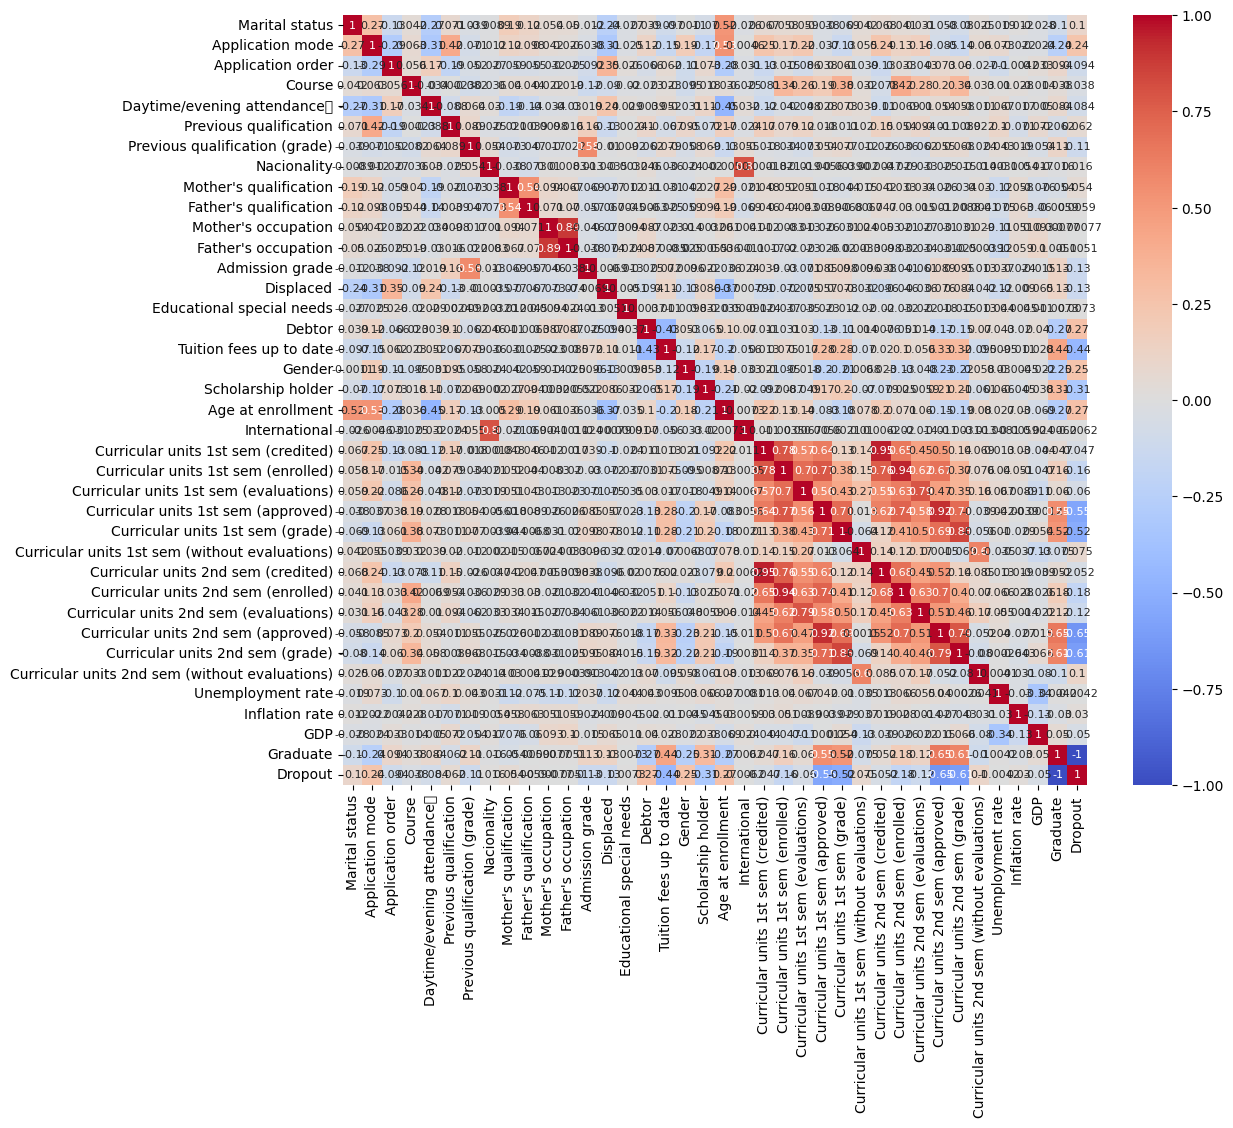

In [75]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_academico = df_academico.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_academico.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

In [ ]:
# 🧑‍🎓 Información Personal
info_personal_cols = [
    'Marital status', 'Gender', 'Age at enrollment', 
    'International', 'Displaced', 'Educational special needs', 'Graduate', 'Dropout'
]
df_info_personal = df_academico[info_personal_cols]

# 🏫 Información Académica (nombre corregido para 'Daytime/evening attendance\t')
info_academica_cols = [
    'Application mode', 'Application order', 'Course', 
    'Daytime/evening attendance\t', 'Previous qualification', 
    'Previous qualification (grade)', 'Admission grade', 'Graduate', 'Dropout'
]
df_info_academica = df_academico[info_academica_cols]

# 📚 Unidades Curriculares - Primer Semestre
unidades_1er_sem_cols = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 
    'Graduate', 'Dropout'
]
df_unidades_1er_sem = df_academico[unidades_1er_sem_cols]

# 📚 Unidades Curriculares - Segundo Semestre
unidades_2do_sem_cols = [
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 
    'Graduate', 'Dropout'
]
df_unidades_2do_sem = df_academico[unidades_2do_sem_cols]

# 👪 Información Familiar
info_familiar_cols = [
    "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation", 'Graduate', 'Dropout'
]
df_info_familiar = df_academico[info_familiar_cols]

# 💵 Información Socioeconómica y Financiera
info_socioeconomica_cols = [
    'Nacionality', 'Scholarship holder', 'Debtor', 'Tuition fees up to date', 'Graduate', 'Dropout'
]
df_info_socioeconomica = df_academico[info_socioeconomica_cols]

# 📈 Indicadores Económicos
indicadores_economicos_cols = [
    'Unemployment rate', 'Inflation rate', 'GDP', 'Graduate', 'Dropout'
]
df_indicadores_economicos = df_academico[indicadores_economicos_cols]

# 📑 Descripción de las Columnas

En esta sección se detallan las columnas del dataset utilizado en el proyecto. Estas se agrupan en categorías para facilitar la comprensión.

---

## 🧑‍🎓 Información Personal

- **Marital status**: Estado civil del estudiante (representado numéricamente).
- **Gender**: Género del estudiante (`0` para hombre, `1` para mujer).
- **Age at enrollment**: Edad del estudiante al momento de la inscripción.
- **International**: Indica si el estudiante es internacional (`1`) o no (`0`).
- **Displaced**: Indica si el estudiante está desplazado (`1`) o no (`0`).
- **Educational special needs**: Indica si el estudiante tiene necesidades educativas especiales (`1`) o no (`0`).

---

## 🏫 Información Académica

- **Application mode**: Modo de aplicación (probablemente relacionado con el tipo de admisión o proceso de inscripción).
- **Application order**: Orden de aplicación, indicando posiblemente en qué orden el estudiante aplicó a diferentes cursos o programas.
- **Course**: Código del curso en el que el estudiante está inscrito.
- **Daytime/evening attendance**: Si el estudiante asiste durante el día o en la noche (`1`: diurno, `0`: nocturno).
- **Previous qualification**: Calificación académica anterior o nivel de estudios previo (representado numéricamente).
- **Previous qualification (grade)**: Calificación promedio o puntuación obtenida en la calificación académica anterior.
- **Admission grade**: Nota o puntuación de admisión del estudiante.

---

## 📚 Unidades Curriculares

### Primer Semestre

- **Curricular units 1st sem (credited)**: Número de unidades curriculares aprobadas en el primer semestre.
- **Curricular units 1st sem (enrolled)**: Número de unidades curriculares inscritas en el primer semestre.
- **Curricular units 1st sem (evaluations)**: Número de evaluaciones en unidades curriculares del primer semestre.
- **Curricular units 1st sem (approved)**: Número de unidades curriculares aprobadas en el primer semestre.
- **Curricular units 1st sem (grade)**: Calificación promedio en las unidades curriculares del primer semestre.
- **Curricular units 1st sem (without evaluations)**: Número de unidades curriculares en el primer semestre sin evaluaciones.

### Segundo Semestre

- **Curricular units 2nd sem (credited)**: Número de unidades curriculares aprobadas en el segundo semestre.
- **Curricular units 2nd sem (enrolled)**: Número de unidades curriculares inscritas en el segundo semestre.
- **Curricular units 2nd sem (evaluations)**: Número de evaluaciones en unidades curriculares del segundo semestre.
- **Curricular units 2nd sem (approved)**: Número de unidades curriculares aprobadas en el segundo semestre.
- **Curricular units 2nd sem (grade)**: Calificación promedio en las unidades curriculares del segundo semestre.
- **Curricular units 2nd sem (without evaluations)**: Número de unidades curriculares en el segundo semestre sin evaluaciones.

---

## 👪 Información Familiar

- **Mother's qualification**: Nivel educativo de la madre (representado numéricamente).
- **Father's qualification**: Nivel educativo del padre (representado numéricamente).
- **Mother's occupation**: Ocupación de la madre (representado numéricamente).
- **Father's occupation**: Ocupación del padre (representado numéricamente).

---

## 💵 Información Socioeconómica y Financiera

- **Nacionality**: Nacionalidad del estudiante (representado numéricamente).
- **Scholarship holder**: Indica si el estudiante es becado (`1`) o no (`0`).
- **Debtor**: Indica si el estudiante tiene deudas (`1`) o no (`0`).
- **Tuition fees up to date**: Indica si las tasas de matrícula están al día (`1`) o no (`0`).

---

## 📈 Indicadores Económicos

- **Unemployment rate**: Tasa de desempleo (posiblemente en el área o región donde vive el estudiante).
- **Inflation rate**: Tasa de inflación (posiblemente en la región o país).
- **GDP**: Producto Interno Bruto (PIB), posiblemente relacionado con la región o país del estudiante.

---

## 🎯 Variable Objetivo

- **Target**: Objetivo de predicción, que indica el estado final del estudiante (por ejemplo, "Dropout" si el estudiante abandonó, "Graduate" si se graduó).

---

## **Notas** 📝

- **Unidades Curriculares**: Varias columnas hacen referencia al desempeño del estudiante en unidades curriculares, tanto en el primer como en el segundo semestre, lo cual puede ser clave para analizar el rendimiento académico.
  
- **Factores Socioeconómicos y Familiares**: Columnas sobre el estado civil, ocupación y educación de los padres, lo cual puede ser relevante para analizar el impacto socioeconómico en el rendimiento académico.
  
- **Factores Económicos**: Las columnas sobre la tasa de desempleo, inflación y PIB pueden ayudar a relacionar factores económicos externos con el desempeño académico del estudiante.

---

Este diseño te ayuda a entender mejor la estructura y relevancia de cada grupo de columnas en el contexto de la predicción del éxito o fracaso académico de los estudiantes. Puedes agregar o ajustar la descripción de acuerdo con el avance del análisis.


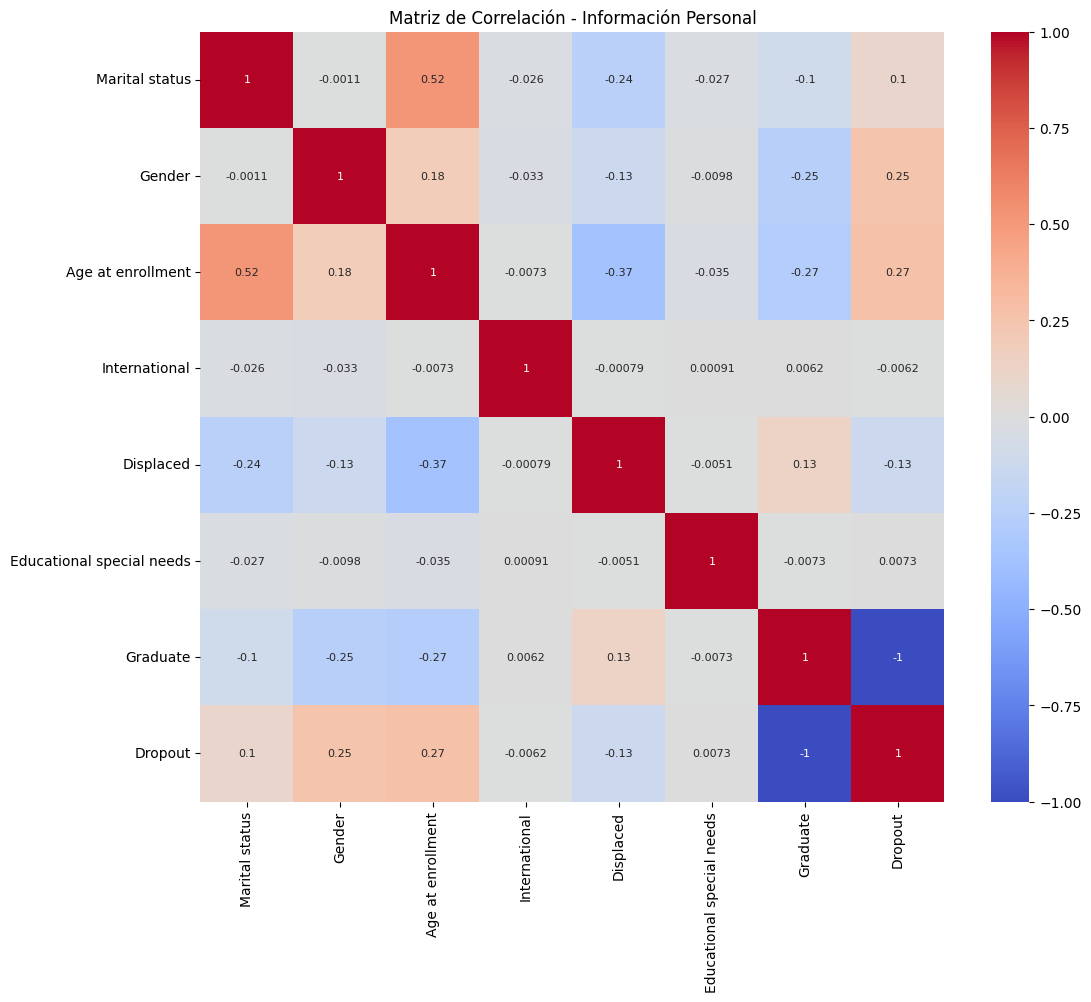

In [81]:
# 🧑‍🎓 Información Personal
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Información Personal')
sns.heatmap(df_info_personal.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

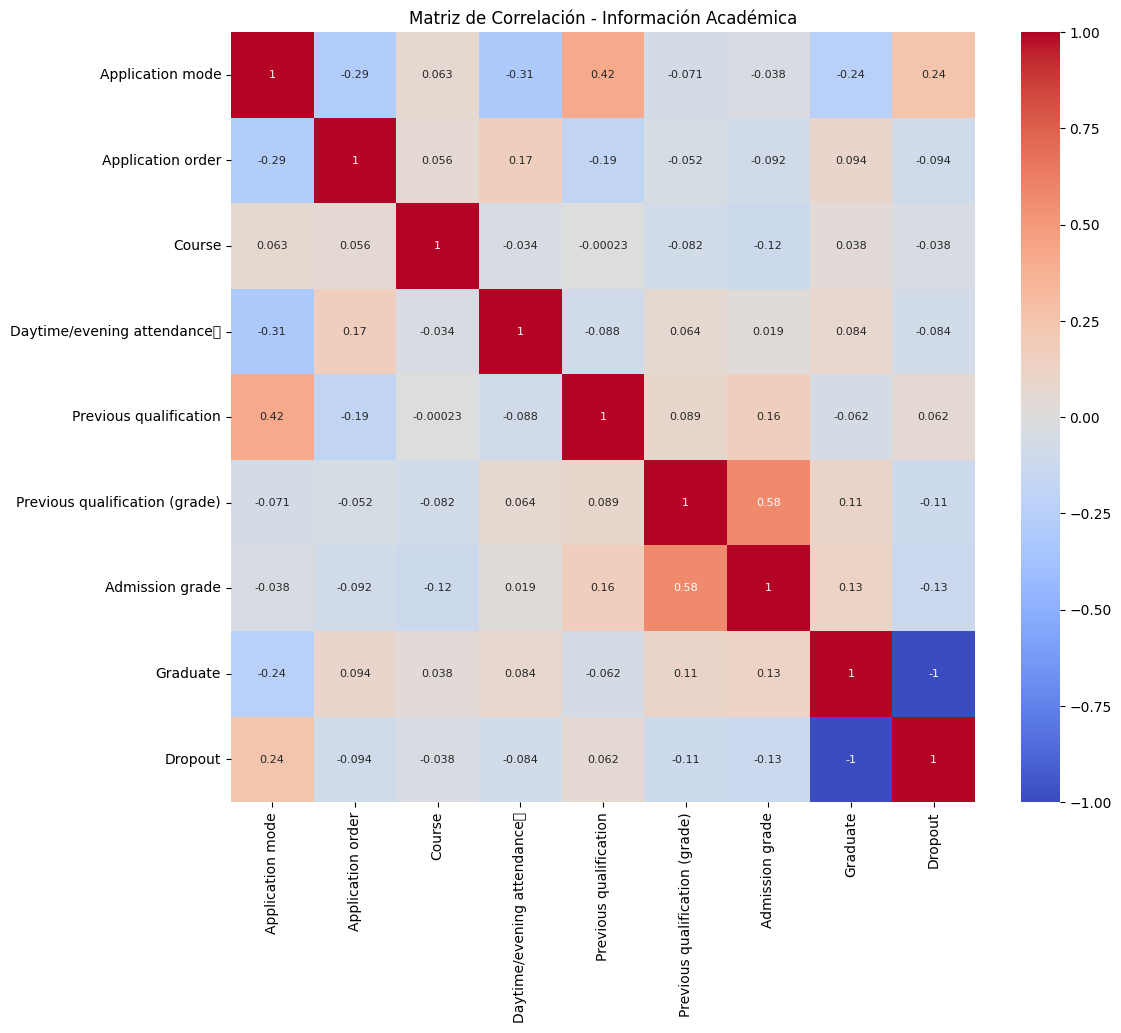

In [82]:
# 🏫 Información Académica
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Información Académica')
sns.heatmap(df_info_academica.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

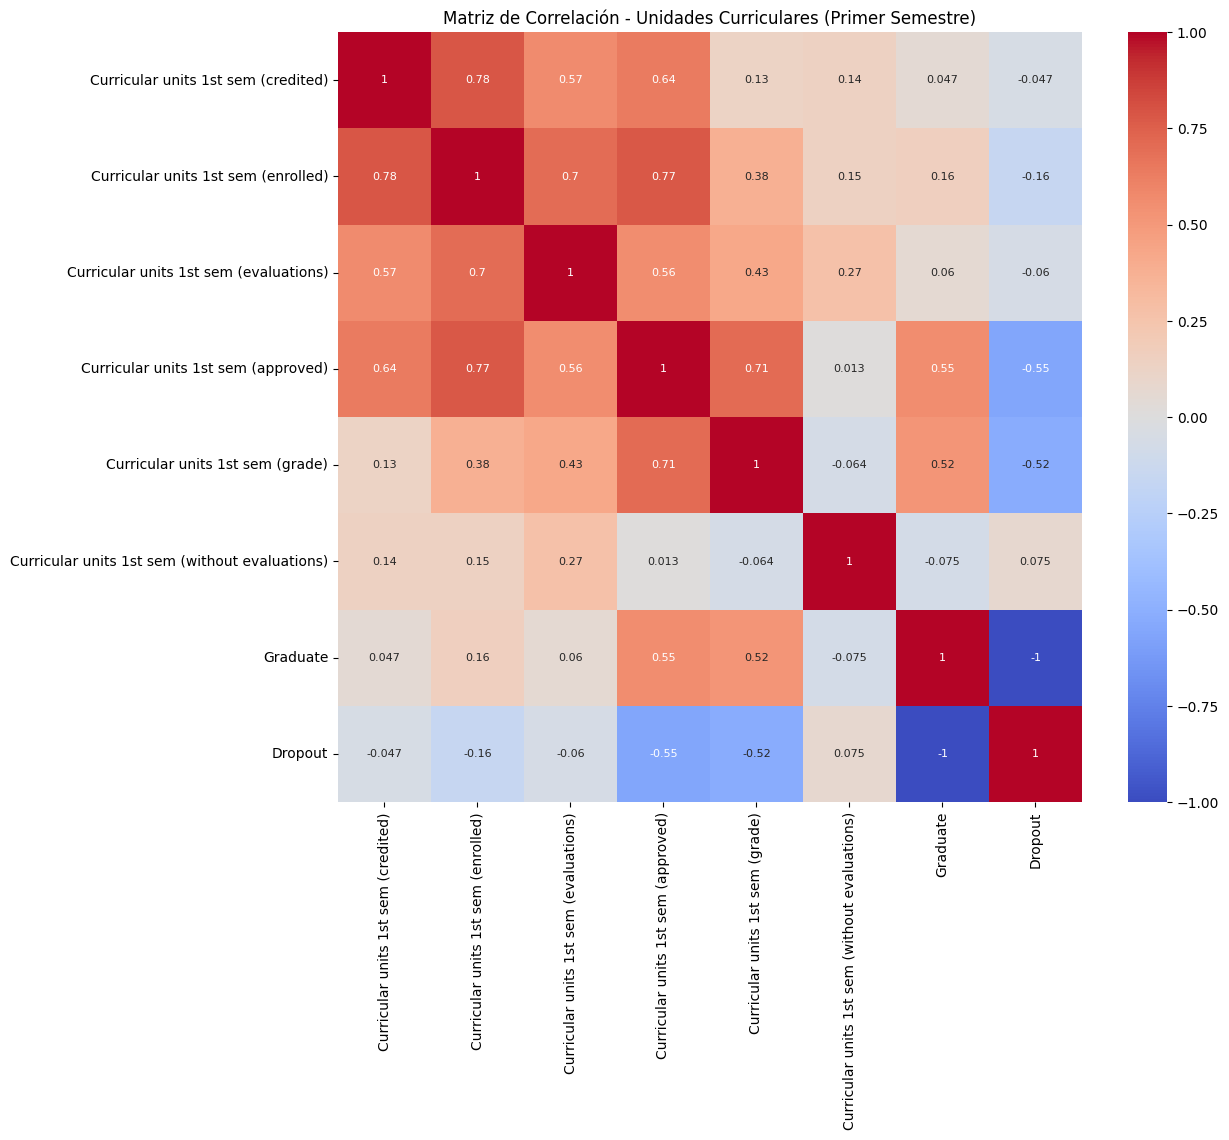

In [83]:
# 📚 Unidades Curriculares - Primer Semestre
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Unidades Curriculares (Primer Semestre)')
sns.heatmap(df_unidades_1er_sem.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

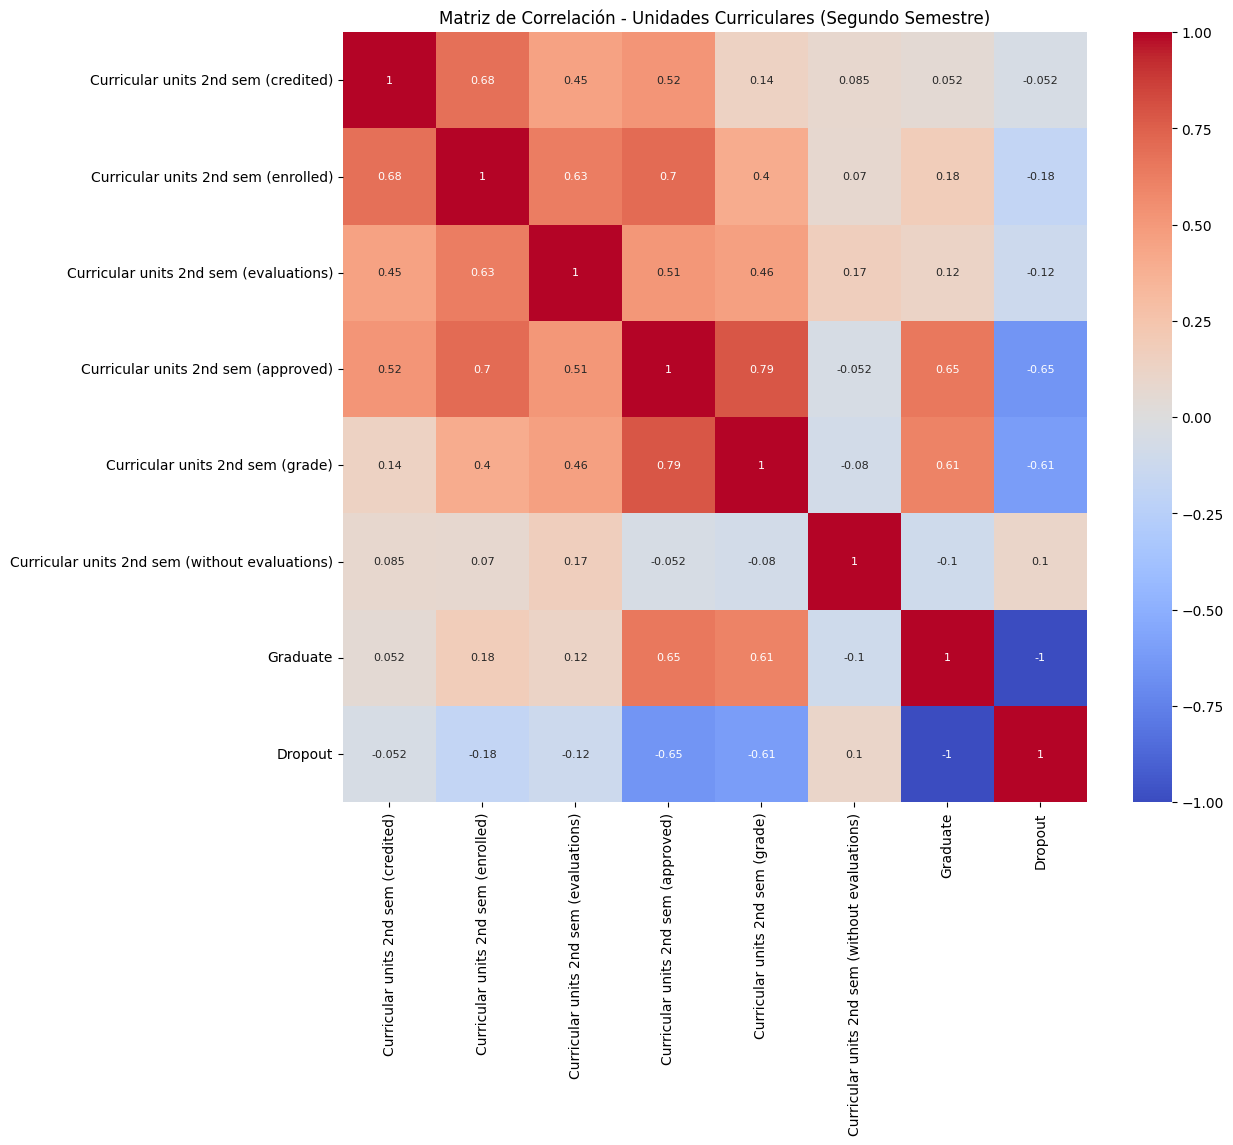

In [84]:
# 📚 Unidades Curriculares - Segundo Semestre
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Unidades Curriculares (Segundo Semestre)')
sns.heatmap(df_unidades_2do_sem.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

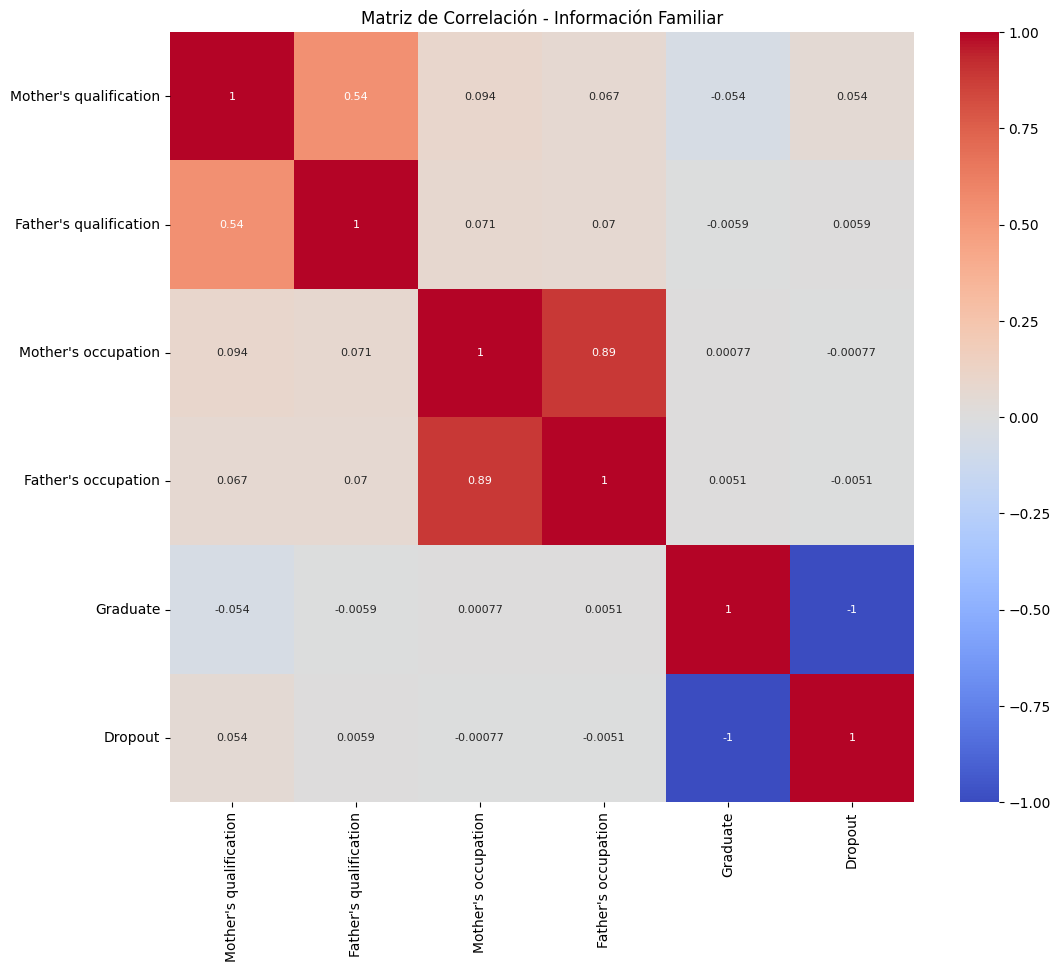

In [85]:
# 👪 Información Familiar
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Información Familiar')
sns.heatmap(df_info_familiar.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

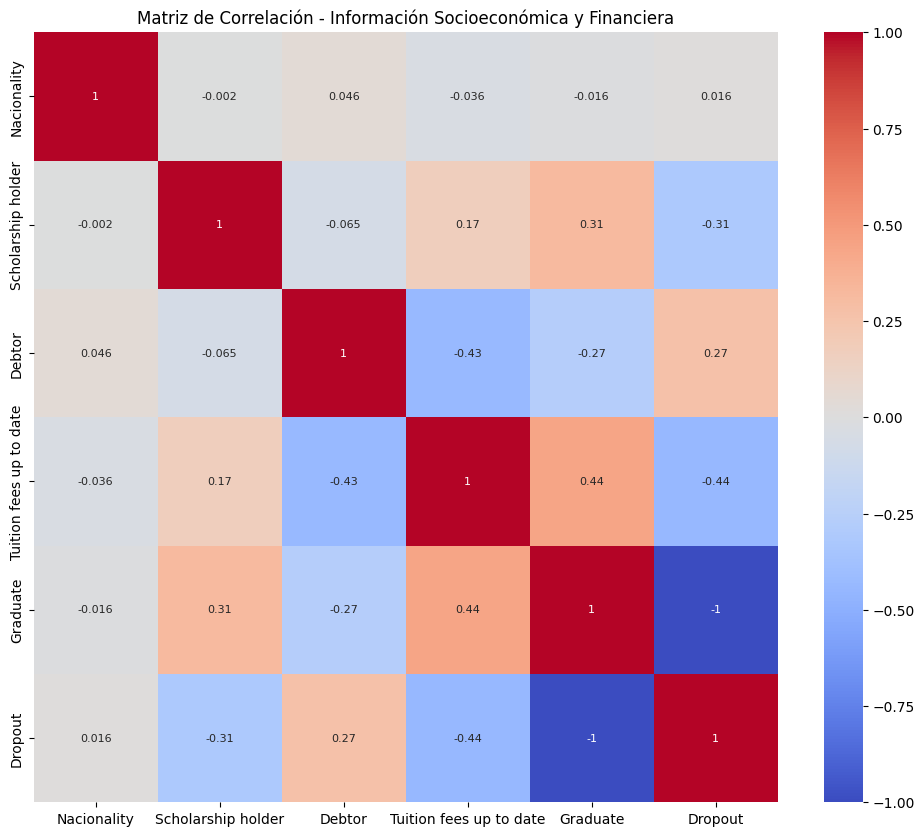

In [86]:
# 💵 Información Socioeconómica y Financiera
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Información Socioeconómica y Financiera')
sns.heatmap(df_info_socioeconomica.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

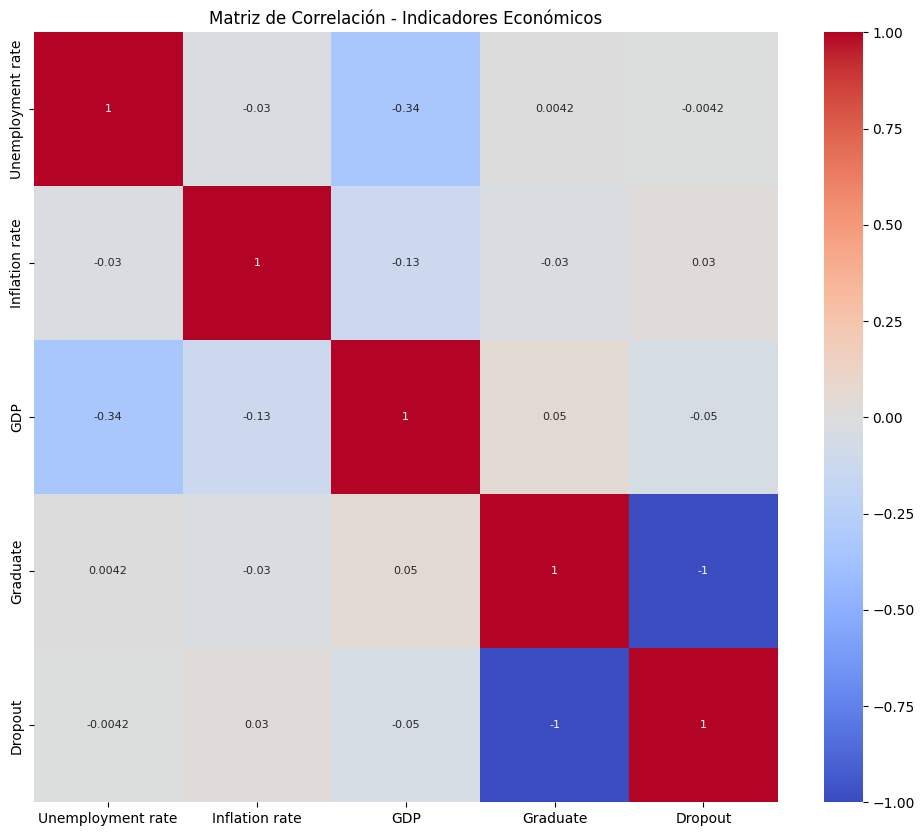

In [87]:
# 📈 Indicadores Económicos
plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación - Indicadores Económicos')
sns.heatmap(df_indicadores_economicos.select_dtypes(include=["number"]).corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

# 
___

# EDUCACION - OTROS DATA SETS

___

## DATA_1

In [ ]:
df = pd.read_csv("./data/Cleaned_Students_Performance.csv", sep=",") # ml/data/Cleaned_Students_Performance.csv
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,0,group B,bachelor's degree,1,0,72,72,74,218,72.666667
1,0,group C,some college,1,1,69,90,88,247,82.333333
2,0,group B,master's degree,1,0,90,95,93,278,92.666667
3,1,group A,associate's degree,0,0,47,57,44,148,49.333333
4,1,group C,some college,1,0,76,78,75,229,76.333333


In [ ]:
df['parental_level_of_education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [ ]:
df['gender'].unique()

array([0, 1])

In [ ]:
df['MUJER'] = (df['gender'] == 0).astype(int)  
df['HOMBRE'] = (df['gender'] == 1).astype(int) 

In [ ]:
conditions = [
    df['parental_level_of_education'] == "master's degree",
    df['parental_level_of_education'].isin(["bachelor's degree", "associate's degree", "some college"]),
    df['parental_level_of_education'].isin(["high school", "some high school"])
]


values = [3, 2, 1] 

df['education_level_numeric'] = np.select(conditions, values, default=0)

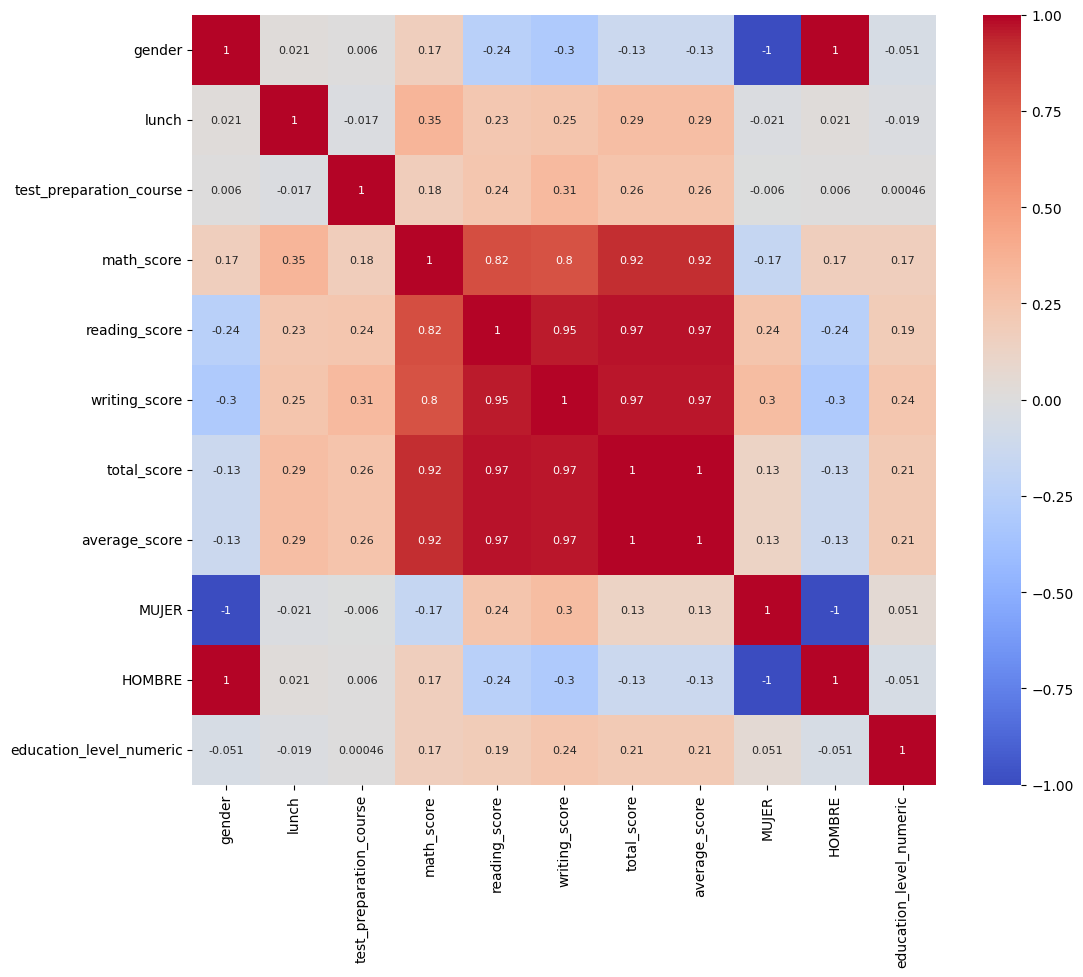

In [ ]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_1 = df.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_1.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

##
___

## DATA_2

In [ ]:
df2 = pd.read_csv("./data/data.csv", sep=",") 
df2.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,19.0,Male,0,9.47080,7.141434,6.03696,4.360278,Unknown,ENFP
1,27.0,Female,0,5.85392,6.160195,0.80552,4.221421,Sports,ESFP
2,21.0,Female,0,7.08615,3.388433,2.66188,5.127320,Unknown,ENFP
3,28.0,Male,0,2.01892,4.823624,7.30625,5.986550,Others,INTP
4,36.0,Female,1,9.91703,4.755080,5.31469,4.677213,Technology,ENFP


In [ ]:
df2['MUJER'] = (df2['Gender'] == "Female").astype(int)  
df2['HOMBRE'] = (df2['Gender'] == "Male").astype(int)

In [ ]:
df2['Interest'].unique()

array(['Unknown', 'Sports', 'Others', 'Technology', 'Arts'], dtype=object)

In [ ]:
df2['Personality'].unique()

array(['ENFP', 'ESFP', 'INTP', 'INFP', 'ENFJ', 'ENTP', 'ESTP', 'ISTP',
       'INTJ', 'INFJ', 'ISFP', 'ENTJ', 'ESFJ', 'ISFJ', 'ISTJ', 'ESTJ'],
      dtype=object)

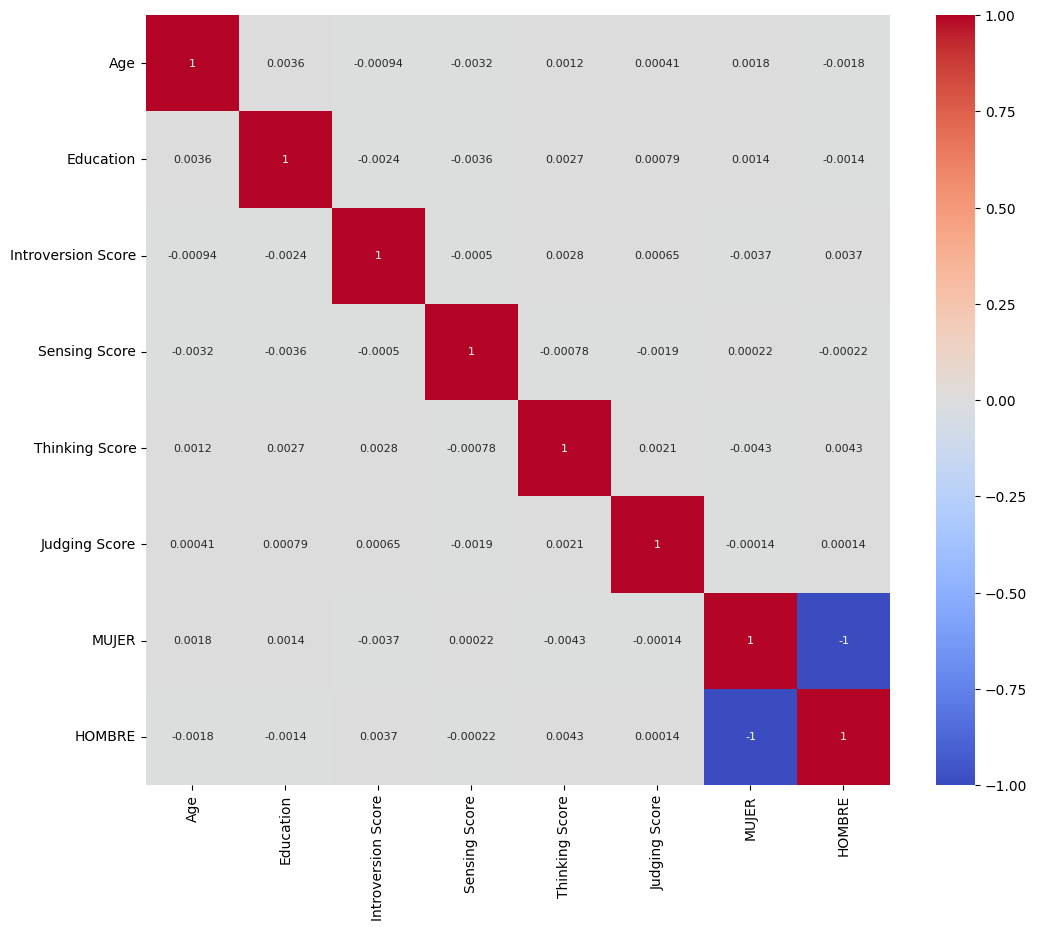

In [ ]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_2 = df2.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_2.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

## 
___

## DATA_3

In [ ]:
df3 = pd.read_csv("./data/student_data.csv", sep=",") 
df3.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


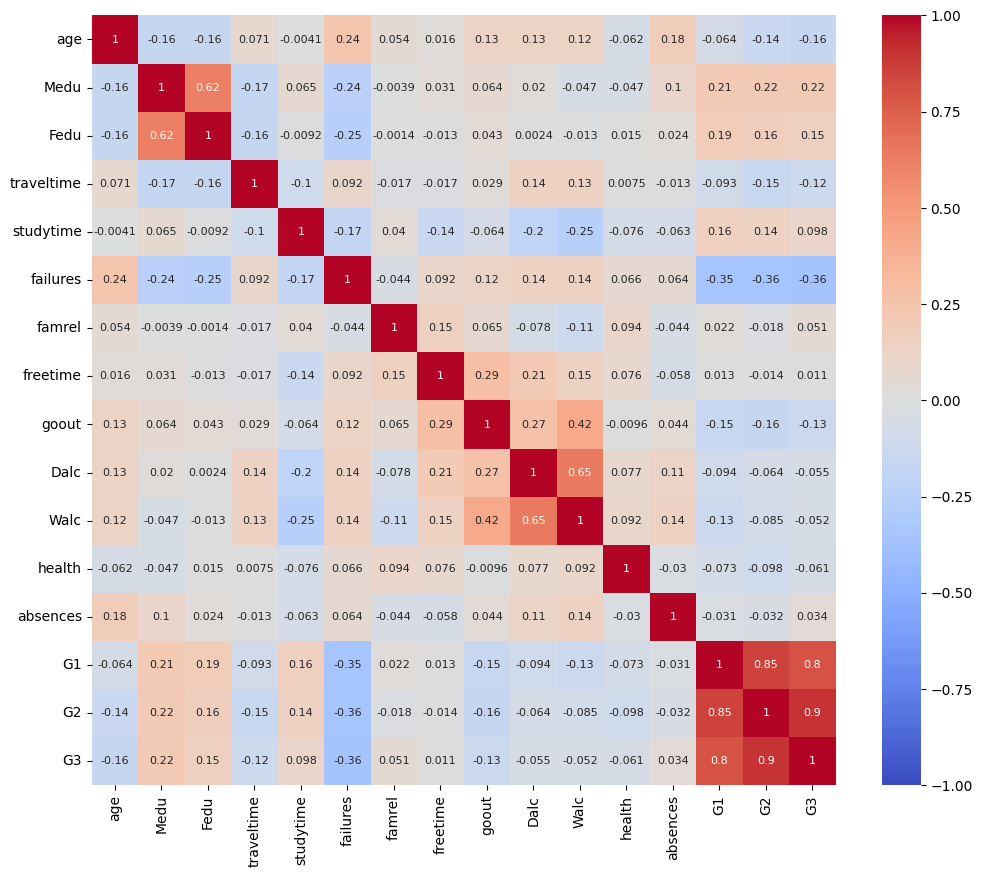

In [ ]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_3 = df3.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_3.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

##
___

## DATA_4

In [ ]:
df4 = pd.read_csv("./data/student_sleep_patterns.csv", sep=",") 
df4.head()

,Student_ID,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,1,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16,4.05,7.41,7.06
1,2,21,Male,1st Year,6.3,6.0,1.9,5,74,2,8.73,7.10,8.21,10.21
2,3,22,Male,4th Year,5.1,6.7,3.9,5,53,5,20.00,20.47,6.88,10.92
3,4,24,Other,4th Year,6.3,8.6,2.8,4,55,9,19.82,4.08,6.69,9.42
4,5,20,Male,4th Year,4.7,2.7,2.7,0,85,3,20.98,6.12,8.98,9.01


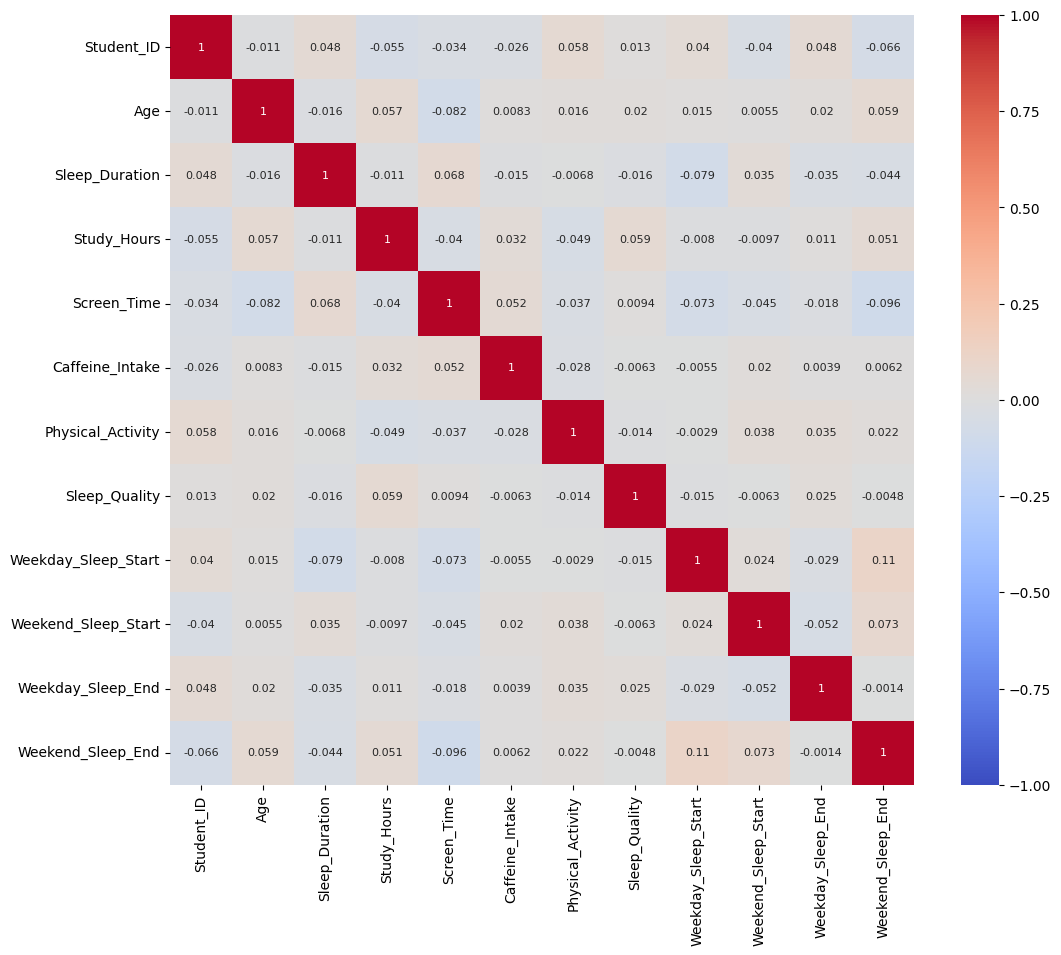

In [ ]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_4 = df4.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_4.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

## 
___

## DATA_5

In [ ]:
df5 = pd.read_csv("./data/StudentPerformanceFactors.csv", sep=",") 
df5.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


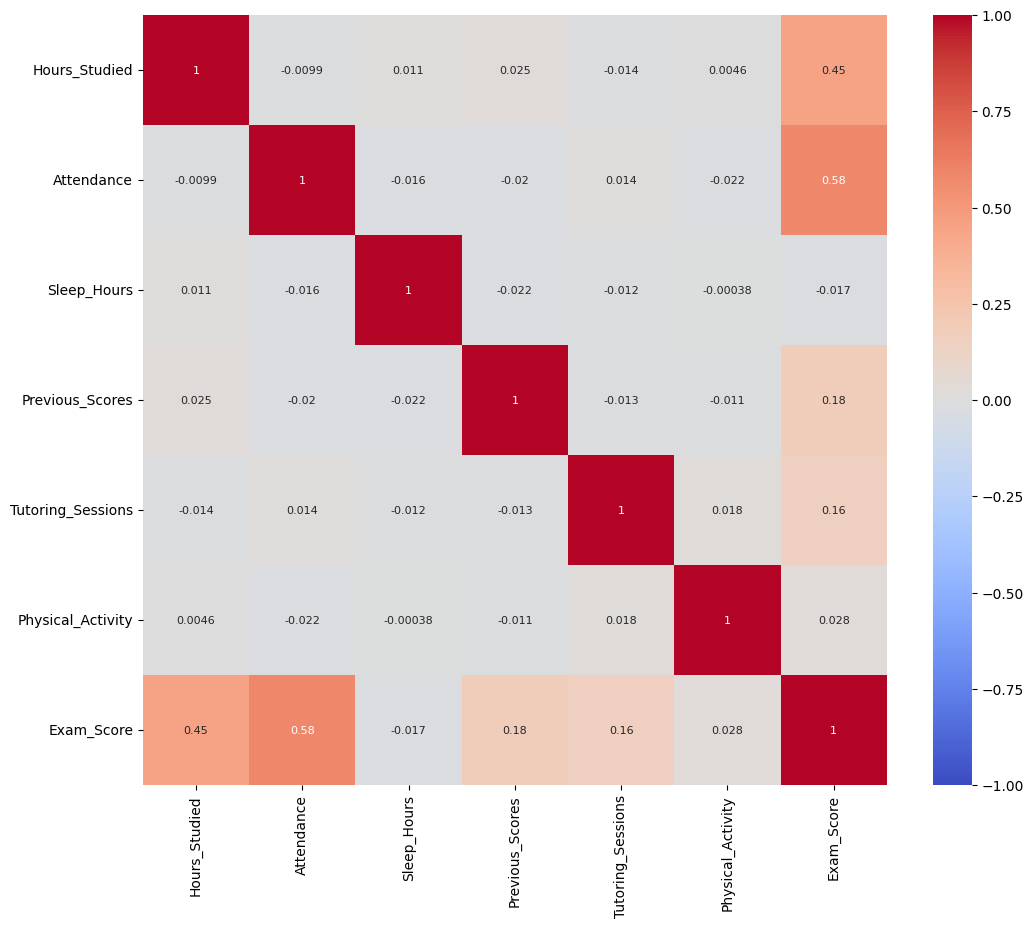

In [ ]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_5 = df5.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_5.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

##
___

## DATA_6

In [ ]:
df6 = pd.read_csv("./data/StudentsPerformance.csv", sep=",") 
df6.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


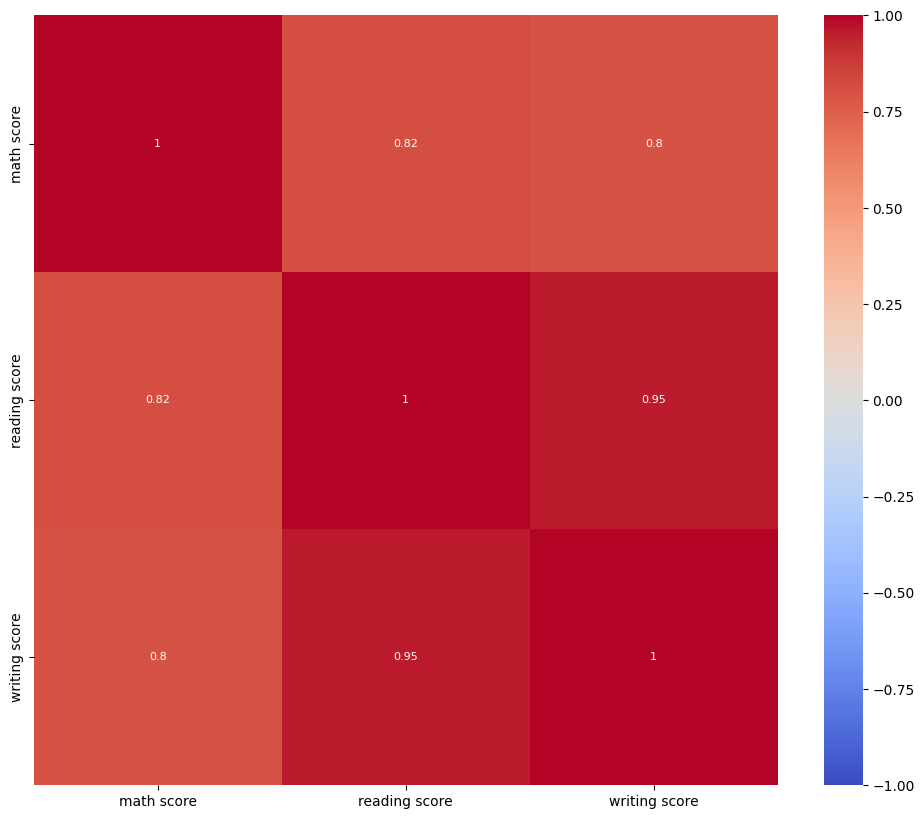

In [ ]:
# SOLO COLUMNAS NUMERICAS 
numeric_df_6 = df6.select_dtypes(include=[float, int])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df_6.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

##
___


## OTROS DATOS

In [ ]:
# https://public.tableau.com/views/EEU2023/InfografiaEEU?%3AshowVizHome=no&%3Aembed=true#3

In [ ]:
# https://www.ucm.es/notas-de-cortess

In [ ]:
# TENGO MAS PDF PERO ESO YA PA ESTE FINDEEEEEEE

#
___

<p align="center">
  <img src="./images/Captura de pantalla 2024-11-07 211344.png" alt="Descripción de la imagen">
</p>